# Evaluation Suite for HyperParam Search Results

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Any, Optional
import robomimic.dev.hparam.metric_fn as Metrics
import copy
from robomimic.dev.hparam.eval_suite import HparamAnalyzer
from matplotlib.collections import PolyCollection
import seaborn as sns

In [4]:
result_dir = '/home/wjung85/Repo/projects/FastIL/logs/hparam_adaptive'
baseline_dir = '/home/wjung85/Repo/projects/FastIL/logs/baseline'

In [5]:
import pickle
pkl_path = "/home/wjung85/Repo/projects/FastIL/logs/hparam/square_image_action_horizon_16_cls_f_ts_20_eta_0_nres_0_loss_mse_wg_10_nsmc_1_stdmc_0_iter_0_2025-01-08 11:11:44.394144.pkl"
with open(pkl_path, "rb") as f:
    data_peek = pickle.load(f)

stat_peek = data_peek["stats"]
demo_peek = data_peek["rollouts"]["demo_0"]

### Loading Result of Baseline (Square)

In [6]:
ldlj_analyzer_bl_success    = HparamAnalyzer(baseline_dir, Metrics.success_wrapper(Metrics.ldlj_pos_eval_fn), level = "demo", filter="inp")
ldlj_analyzer_bl            = HparamAnalyzer(baseline_dir, Metrics.ldlj_pos_eval_fn, level = "demo", filter="inp")
sparc_analyzer_bl_success   = HparamAnalyzer(baseline_dir, Metrics.success_wrapper(Metrics.sparc_pos_eval_fn), level = "demo", filter="inp")
sparc_analyzer_bl           = HparamAnalyzer(baseline_dir, Metrics.sparc_pos_eval_fn, level = "demo", filter="inp")
horizon_analyzer_bl_success = HparamAnalyzer(baseline_dir, Metrics.success_wrapper(Metrics.horizon_eval_fn), level = "demo", filter="inp")
horizon_analyzer_bl         = HparamAnalyzer(baseline_dir, Metrics.horizon_eval_fn, level = "demo", filter="inp")
avg_success_analyzer_bl       = HparamAnalyzer(baseline_dir, Metrics.average_success_eval_fn, level = "stat", filter="inp")
inftime_analyzer_bl           = HparamAnalyzer(baseline_dir, Metrics.average_inftime_eval_fn, level = "demo", filter="inp")
sparc_knot_analyzer_bl          = HparamAnalyzer(baseline_dir, Metrics.sparc_pos_real_at_knot_eval_fn, level = "demo", filter="inp")
sparc_knot_analyzer_bl_success  = HparamAnalyzer(baseline_dir, Metrics.success_wrapper(Metrics.sparc_pos_real_at_knot_eval_fn), level = "demo", filter="inp")

100%|██████████| 6/6 [00:00<00:00,  6.57it/s]


In [ ]:
_ = avg_success_analyzer_bl.plot_hparam_comparison(x_param='ts', plot_type='violin', figsize=(1, 3), metric_name = "succ")

### Loading Result of Inpainting (Square)

In [ ]:
ldlj_analyzer_inp_success    = HparamAnalyzer(result_dir, Metrics.success_wrapper(Metrics.ldlj_pos_eval_fn), level = "demo", filter="inp")
ldlj_analyzer_inp            = HparamAnalyzer(result_dir, Metrics.ldlj_pos_eval_fn, level = "demo", filter="inp")
sparc_analyzer_inp_success   = HparamAnalyzer(result_dir, Metrics.success_wrapper(Metrics.sparc_pos_eval_fn), level = "demo", filter="inp")
sparc_analyzer_inp          = HparamAnalyzer(result_dir, Metrics.sparc_pos_eval_fn, level = "demo", filter="inp")
# horizon_analyzer_inp_success = HparamAnalyzer(result_dir, Metrics.success_wrapper(Metrics.horizon_eval_fn), level = "demo", filter="inp")
# horizon_analyzer_inp         = HparamAnalyzer(result_dir, Metrics.horizon_eval_fn, level = "demo", filter="inp")
avg_success_analyzer_inp       = HparamAnalyzer(result_dir, Metrics.average_success_eval_fn, level = "stat", filter="inp")
inftime_analyzer_inp           = HparamAnalyzer(result_dir, Metrics.average_inftime_eval_fn, level = "demo", filter="inp")
sparc_knot_analyzer_inp        = HparamAnalyzer(result_dir, Metrics.sparc_pos_real_at_knot_eval_fn, level = "demo", filter="inp")
# sparc_knot_analyzer_inp_success  = HparamAnalyzer(result_dir, Metrics.success_wrapper(Metrics.sparc_pos_real_at_knot_eval_fn), level = "demo", filter="inp")

### Inference Time

In [ ]:
df = inftime_analyzer_inp.plot_hparam_comparison(x_param='ts', plot_type='violin', fixed_params={"nres": 1}, figsize=(4, 2), metric_name = "inf_time")
df = inftime_analyzer_inp.plot_hparam_comparison(x_param='nres', plot_type='violin', fixed_params={"ts":100}, figsize=(4, 2), metric_name = "inf_time")
df = inftime_analyzer_inp.plot_hparam_comparison(x_param='ts', y_param = "nres", figsize=(6, 3), metric_name = "inf_time")

### Success Rate

This result is for the 1x policy. So the success rate would not be a good metric.

In [ ]:
df = avg_success_analyzer_inp.plot_hparam_comparison(x_param='ts', plot_type='violin', fixed_params={"nres": 0}, figsize=(6, 3), metric_name = "succ")
df = avg_success_analyzer_inp.plot_hparam_comparison(x_param='nres', plot_type='violin', fixed_params={"ts": 100}, figsize=(6, 3), metric_name = "succ")
df = avg_success_analyzer_inp.plot_hparam_comparison(x_param='eta', plot_type='violin', figsize=(6, 3), metric_name = "succ")
df = avg_success_analyzer_inp.plot_hparam_comparison(x_param='ts', y_param = "nres", figsize=(6, 3), metric_name = "succ")

### LDLJ

In [ ]:
df = ldlj_analyzer_inp.plot_hparam_comparison(x_param='ts', plot_type='violin', fixed_params={"nres": 1}, figsize=(6, 3), metric_name = "ldlj")
df = ldlj_analyzer_inp.plot_hparam_comparison(x_param='nres', plot_type='violin', fixed_params={"ts":100}, figsize=(6, 3), metric_name = "ldlj")
df = ldlj_analyzer_inp.plot_hparam_comparison(x_param='eta', plot_type='violin', figsize=(6, 3), metric_name = "ldlj")
df = ldlj_analyzer_inp.plot_hparam_comparison(x_param='ts', y_param = "nres", figsize=(6, 3), metric_name = "ldlj")

### SPARC

In [ ]:
df = sparc_analyzer_inp.plot_hparam_comparison(x_param='ts', plot_type='violin', fixed_params={"nres": 1}, figsize=(6, 3), metric_name = "sparc")
df = sparc_analyzer_inp.plot_hparam_comparison(x_param='nres', plot_type='violin', fixed_params={"ts":100}, figsize=(6, 3), metric_name = "sparc")
df = sparc_analyzer_inp.plot_hparam_comparison(x_param='eta', plot_type='violin', figsize=(6, 3), metric_name = "sparc")
df = sparc_analyzer_inp.plot_hparam_comparison(x_param='ts', y_param = "nres", figsize=(6, 3), metric_name = "sparc")
sparc_analyzer_inp.get_best_config(maximize=True)

### Evaluation Function Suite

In [ ]:
_ = ldlj_analyzer_inp.plot_hparam_comparison(x_param='ts', plot_type='violin', fixed_params={"nres": 1}, figsize=(6, 3), metric_name = "ldlj")
_ = ldlj_analyzer_inp_success.plot_hparam_comparison(x_param='ts', plot_type='violin', fixed_params={"nres": 1}, figsize=(6, 3), metric_name = "ldlj")

We want to analyze the scenario up to 

Hypothesis 1. Enabling inpainting leads to more success
Hypothesis 2. More smoothness Hypothesis 3: Consistent Prediction leads to more success rate

In [ ]:
_ = sparc_analyzer_inp.plot_hparam_comparison(x_param='ts', plot_type='box', fixed_params={"nres": 1}, figsize=(6, 3), metric_name = "sparc", ylim=[-5.5, -3])
_ = sparc_analyzer_inp_success.plot_hparam_comparison(x_param='ts', plot_type='box', fixed_params={"nres": 1}, figsize=(6, 3), metric_name = "sparc", ylim=[-5.5, -3])

### Success Rate Evaluation

### Average Horizon Evaluation

In [ ]:
avg_horizon_analyzer = HparamAnalyzer(result_dir, horizon_eval_fn, level="stat", filter="inp")

In [ ]:
# Example: Plot comparison with fixed parameters
avg_horizon_analyzer.plot_hparam_comparison(x_param='nres', plot_type='box', fixed_params={"inp": True})

# Get best configuration
best_config = avg_horizon_analyzer.get_best_config(maximize=True)
print("Best configuration:", best_config)

### Inferenece Time

In [ ]:
inftime_analyzer = HparamAnalyzer(result_dir, inftime_eval_fn, level="demo", filter="inp")

In [ ]:
inftime_analyzer.plot_hparam_comparison(x_param='nres', plot_type='box', fixed_params={"inp": True, "ts": 40})

# Get best configuration
best_config = inftime_analyzer.get_best_config(maximize=True)
print("Best configuration:", best_config)

### Smoothness

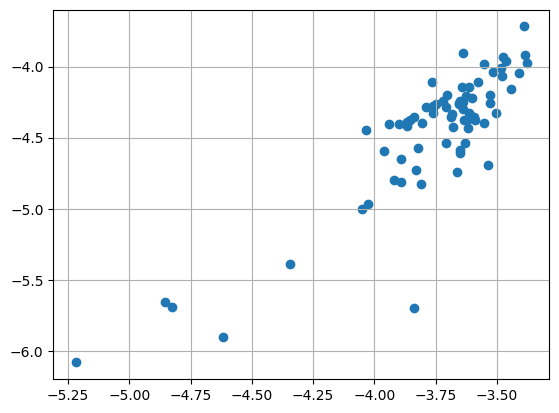

In [7]:
from robomimic.dev.smoothness_metrics.compute_smoothness_metrics import compute_sparc, compute_LDLJ

pkl_path = "/home/wjung85/Repo/projects/FastIL/logs/hparam/square_image_action_horizon_16_inp_t_ts_40_eta_1_nres_1_iter_0_2025-01-08 14:01:21.391115.pkl"
with open(pkl_path, 'rb') as f:
    data = pickle.load(f)

positions_cmd_vec, positions_real_vec = [], []
sparc_cmd_vec, sparc_real_vec = [], []

for demo_id, ret in data["rollouts"].items():
    positions_real = np.array([step['robot0_eef_pos'][-1] for step in ret["obs"]])
    positions_cmd  = np.array(ret['executed_actions'])[:, :3]

    # sparc_cmd_vec.append(compute_LDLJ(positions_cmd))
    # sparc_real_vec.append(compute_LDLJ(positions_real))

    sparc_cmd_vec.append(compute_sparc(positions_cmd, dt=0.05))
    sparc_real_vec.append(compute_sparc(positions_real, dt=0.05))

plt.scatter(np.array(sparc_real_vec), np.array(sparc_cmd_vec))
plt.grid(True)

Text(0, 0.5, 'SPARC')

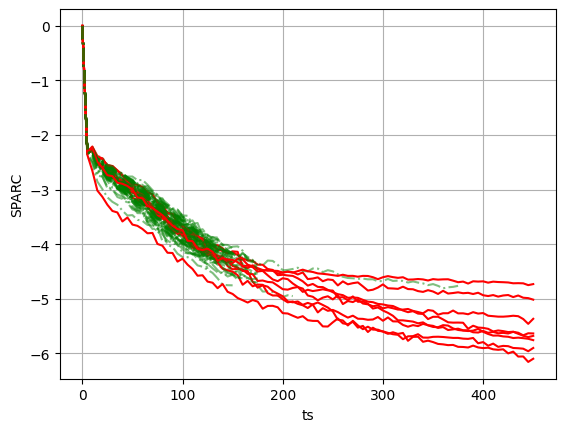

In [55]:
N_skip = 5
success_vec = data["stats"]["Success_Rate"]
for i, demo in enumerate(data["rollouts"].values()):
    position_i = np.array(demo['executed_actions'])[:, :3]
    dt = 1/demo['kwargs']['fast_control_freq']
    sparc_vec_i = []

    t_eval = np.arange(0, position_i.shape[0], N_skip)
    for j in t_eval:
        sparc_ij = Metrics.compute_sparc(position_i[:j], dt)
        sparc_vec_i.append(sparc_ij)
    color = "green" if success_vec[i] else "red"
    alpha = 0.5 if success_vec[i] else 1
    linestyle = "-." if success_vec[i] else "-"
    plt.plot(t_eval, sparc_vec_i, color, alpha=alpha, linestyle=linestyle)

plt.grid(True)
plt.xlabel("ts")
plt.ylabel("SPARC")


Succ 0
Fail 1
LongSucc 29
Succ 39
Fail 50
Succ 62


Text(0, 0.5, 'SPARC')

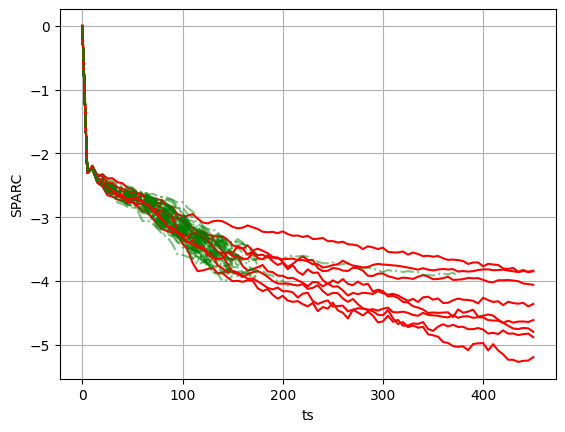

In [63]:
N_skip = 5
success_vec = data["stats"]["Success_Rate"]
for i, demo in enumerate(data["rollouts"].values()):
    position_i = Metrics.get_end_effector_position(demo, type="real")
    dt = 1/demo['kwargs']['fast_control_freq']
    sparc_vec_i = []

    t_eval = np.arange(0, position_i.shape[0], N_skip)
    for j in t_eval:
        sparc_ij = Metrics.compute_sparc(position_i[:j], dt)
        sparc_vec_i.append(sparc_ij)
    color = "green" if success_vec[i] else "red"
    alpha = 0.5 if success_vec[i] else 1
    linestyle = "-." if success_vec[i] else "-"
    plt.plot(t_eval, sparc_vec_i, color, alpha=alpha, linestyle=linestyle)

    if (np.array(sparc_vec_i).min() > -4) and not success_vec[i]:
        print("Fail", i)

    if (np.array(sparc_vec_i).min() < -4) and success_vec[i]:
        print("Succ", i)

    if np.array(sparc_vec_i).shape[0] > 60 and success_vec[i]:
        print("LongSucc", i)

plt.grid(True)
plt.xlabel("ts")
plt.ylabel("SPARC")


Text(0, 0.5, 'LDLJ')

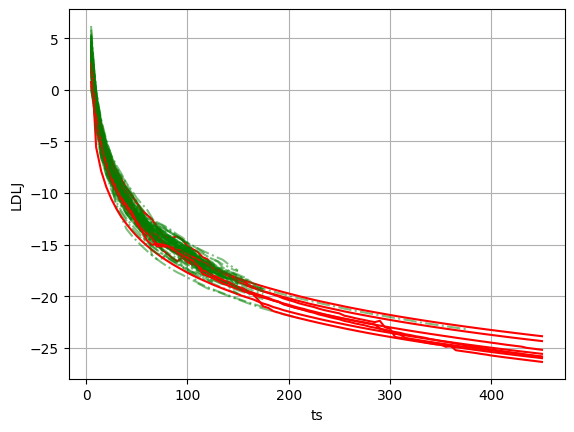

In [50]:
N_skip = 5
success_vec = data["stats"]["Success_Rate"]
for i, demo in enumerate(data["rollouts"].values()):
    position_i = Metrics.get_end_effector_position(demo, type="real")
    sparc_vec_i = []

    t_eval = np.arange(N_skip, position_i.shape[0], N_skip)
    for j in t_eval:
        sparc_ij = Metrics.compute_LDLJ(position_i[:j])
        sparc_vec_i.append(sparc_ij)
    color = "green" if success_vec[i] else "red"
    alpha = 0.5 if success_vec[i] else 1
    linestyle = "-." if success_vec[i] else "-"
    plt.plot(t_eval, sparc_vec_i, color, alpha=alpha, linestyle=linestyle)

plt.grid(True)
plt.xlabel("ts")
plt.ylabel("LDLJ")

In [48]:
np.linalg.norm(np.diff(position_i, axis=0), axis=1).max()

0.011914234401895096

In [14]:
demo['executed_actions']

TypeError: list indices must be integers or slices, not tuple

In [ ]:
demo = data["rollouts"]["demo_1"]
margin       = 12
positions = np.array(demo['executed_actions'])[:, :3]
n_transitions = positions.shape[0]
n_inf        = demo['num_inferences']
Ta           = get_Ta(demo)
dt           = 1/demo["kwargs"]["fast_control_freq"]

sparc_vec = []
for i in range(n_transitions):
    start = max(i - margin, 0)
    end   = min(i + margin, n_transitions)
    positions_near_knot = positions[start:end]
    # sparc_vec.append(compute_LDLJ(positions_near_knot))
    sparc_vec.append(compute_sparc(positions_near_knot, dt = dt))
    
sparc_vec = np.array(sparc_vec)



In [ ]:
knots = np.arange(n_inf)*Ta

plt.plot(np.arange(n_transitions), sparc_vec)
plt.scatter(knots, sparc_vec[knots], color="red", marker="o")

In [ ]:
sparc_real_analyzer = HparamAnalyzer(result_dir, sparc_pos_real_eval_fn, level="demo", filter="inp")
sparc_cmd_analyzer  = HparamAnalyzer(result_dir, sparc_pos_cmd_eval_fn, level="demo", filter="inp")
ldlj_real_analyzer  = HparamAnalyzer(result_dir, ldlj_pos_real_eval_fn, level="demo", filter="inp")
ldlj_cmd_analyzer  = HparamAnalyzer(result_dir, ldlj_pos_cmd_eval_fn, level="demo", filter="inp")

In [ ]:
# sparc_real_analyzer.plot_hparam_comparison(x_param='ts', plot_type='box', fixed_params={"inp": True, "nres": 0, "eta": 1, "iter": 0})
success_analyzer.plot_hparam_comparison(x_param='ts', plot_type='violin', fixed_params={"inp": True, "nres": 0, "eta": 0})
inftime_analyzer.plot_hparam_comparison(x_param='ts', plot_type='violin', fixed_params={"inp": True, "nres": 0, "eta": 1})
ldlj_real_analyzer.plot_hparam_comparison(x_param='ts', plot_type='violin', fixed_params={"inp": True, "nres": 0, "eta": 0})

# Get best configuration
best_config = sparc_real_analyzer.get_best_config(maximize=True)
print("Best configuration:", best_config)

In [ ]:
ldlj_real_analyzer.plot_hparam_comparison(x_param='ts', plot_type='violin', fixed_params={"inp": True})

# Get best configuration
best_config = ldlj_real_analyzer.get_best_config(maximize=True)
print("Best configuration:", best_config)

In [ ]:
# Additional Experiments

knot_length_vec = range(5, 400)
sparc_vec = []
for knot_length in knot_length_vec:
    sparc_i = Metrics.ldlj_pos_cmd_at_knot_eval_fn(demo_peek, knot_length)
    sparc_vec.append(sparc_i)

plt.plot(knot_length_vec, sparc_vec)
plt.xlabel("knot length")
plt.ylabel("LDLJ")